In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mohankrishnathalla/global-ai-adoption-and-workforce-impact-dataset/ai_industry_summary.csv
/kaggle/input/datasets/mohankrishnathalla/global-ai-adoption-and-workforce-impact-dataset/ai_company_adoption.csv
/kaggle/input/datasets/mohankrishnathalla/global-ai-adoption-and-workforce-impact-dataset/country_ai_index.csv


## Problem Statement

**Why AI Adoption Matters:**

Artificial Intelligence  adoption is transforming industries worldwide. Companies leveraging AI gain efficiency, productivity, and innovation advantages. Understanding which factors drive AI adoption and how it impacts workforce productivity is crucial for executives, policymakers, and researchers.

**Objectives of this Notebook:**

- Explore global AI adoption patterns by region, industry, and company size.

- Analyze productivity and workforce impact of AI.

- Build predictive models for AI adoption and interpret feature importance.

## Import Libraries

In [2]:


import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import shap

sns.set_theme(style="whitegrid")


## LOAD DATASETS

**We have 3 datasets:**

- df_adoption: Company-level AI adoption survey

- df_industry: Industry summary metrics

- df_country: Country-level AI index

In [3]:

path = "/kaggle/input/datasets/mohankrishnathalla/global-ai-adoption-and-workforce-impact-dataset/"
df_adoption = pd.read_csv(os.path.join(path, "ai_company_adoption.csv"))
df_industry = pd.read_csv(os.path.join(path, "ai_industry_summary.csv"))
df_country = pd.read_csv(os.path.join(path, "country_ai_index.csv"))
print("Datasets loaded successfully!")

Datasets loaded successfully!


##   DATA CLEANING

- Outliers were removed to avoid skewing the model.

- All missing values handled: categorical → mode, numerical → median.

In [4]:

# Fill missing categorical with mode, numerical with median
for col in df_adoption.columns:
    if df_adoption[col].dtype == 'object':
        df_adoption[col] = df_adoption[col].fillna(df_adoption[col].mode()[0])
    else:
        df_adoption[col] = df_adoption[col].fillna(df_adoption[col].median())

# Outlier handling using IQR
outlier_cols = ['num_employees', 'annual_revenue_usd_millions', 'ai_investment_per_employee', 'productivity_change_percent']
for col in outlier_cols:
    Q1 = df_adoption[col].quantile(0.25)
    Q3 = df_adoption[col].quantile(0.75)
    IQR = Q3 - Q1
    df_adoption = df_adoption[(df_adoption[col] >= Q1 - 1.5*IQR) & (df_adoption[col] <= Q3 + 1.5*IQR)]

# Map quarter to month
q_to_m = {'Q1':'01', 'Q2':'04', 'Q3':'07', 'Q4':'10'}
df_adoption['survey_date'] = pd.to_datetime(df_adoption['survey_year'].astype(str) + '-' + df_adoption['quarter'].map(q_to_m) + '-01')


##  FEATURE ENGINEERING
- Categorical variables are encoded.

- Features selected based on business relevance and correlation.

- StandardScaler ensures numeric features are normalized.

In [5]:


df_ml = df_adoption.copy()
categorical_features = ['quarter','region','industry','company_size','ai_adoption_stage',
                        'ai_primary_tool','ai_use_case','data_privacy_level','ai_ethics_committee']
le = LabelEncoder()
for col in categorical_features:
    df_ml[col] = le.fit_transform(df_ml[col])

# Feature selection
features = ['survey_year','region','industry','company_size','num_employees','annual_revenue_usd_millions',
            'company_age','years_using_ai','num_ai_tools_used','ai_projects_active','ai_training_hours',
            'ai_budget_percentage','ai_maturity_score','ai_investment_per_employee','regulatory_compliance_score',
            'ai_risk_management_score','remote_work_percentage','task_automation_rate','productivity_change_percent']
target = 'ai_adoption_rate'

X = df_ml[features]
y = df_ml[target]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## EXPLORATORY DATA ANALYSIS 

**EDA Insight:**
- **AI Maturity Score** and **Task Automation Rate** show strong positive correlation with **AI Adoption Rate**.

- **Company Size** has moderate correlation; revenue and employees show weaker correlations.

  
**AI Maturity vs AI Adoption Rate**

- Larger companies with higher AI maturity adopt AI faster.

- Finance and tech industries lead adoption.

  
**Productivity vs AI Budget %**
 

  - Higher AI budget correlates with higher productivity gains.

  - Industries like Finance and Tech show the largest ROI.

**Boxplot: Productivity Change by Company Siz**e

  - Large companies see a wider range of productivity improvements.

  - Medium-sized companies adopt AI more consistently.

/tmp/ipykernel_17/2213789177.py:21: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




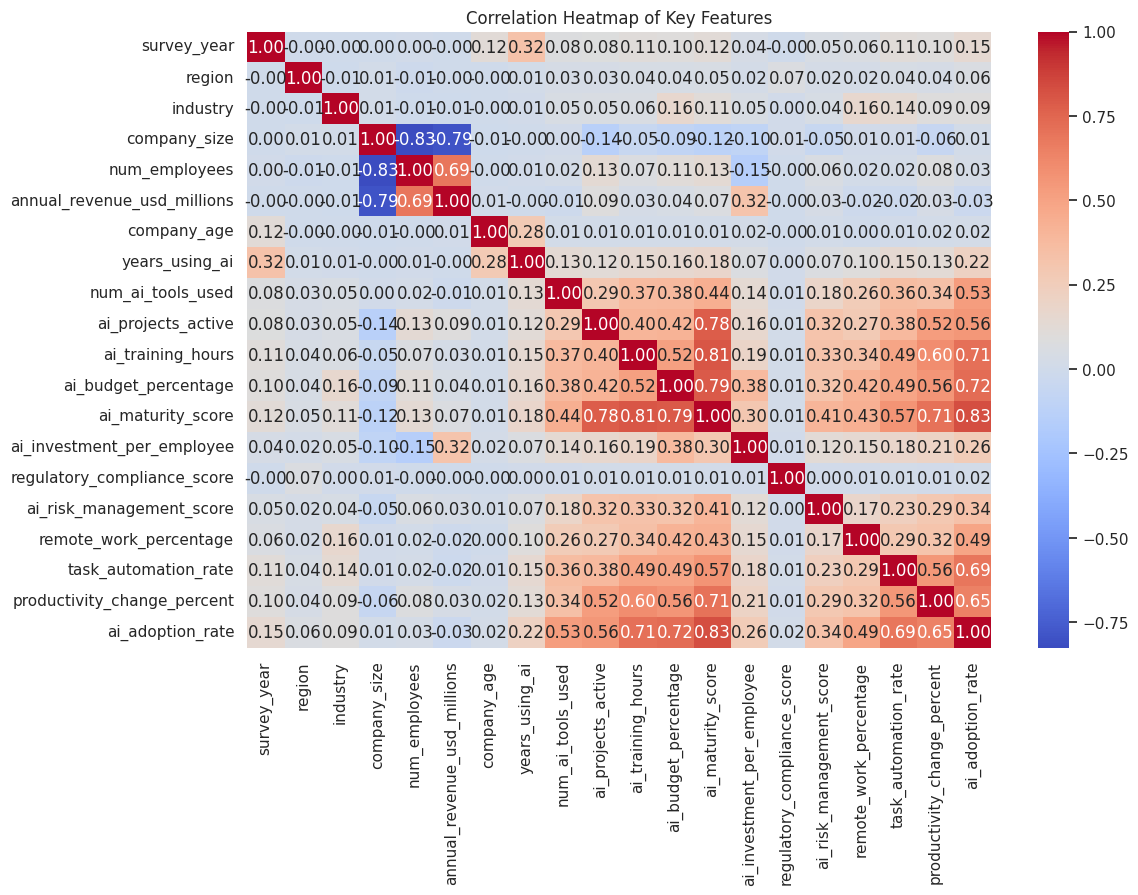

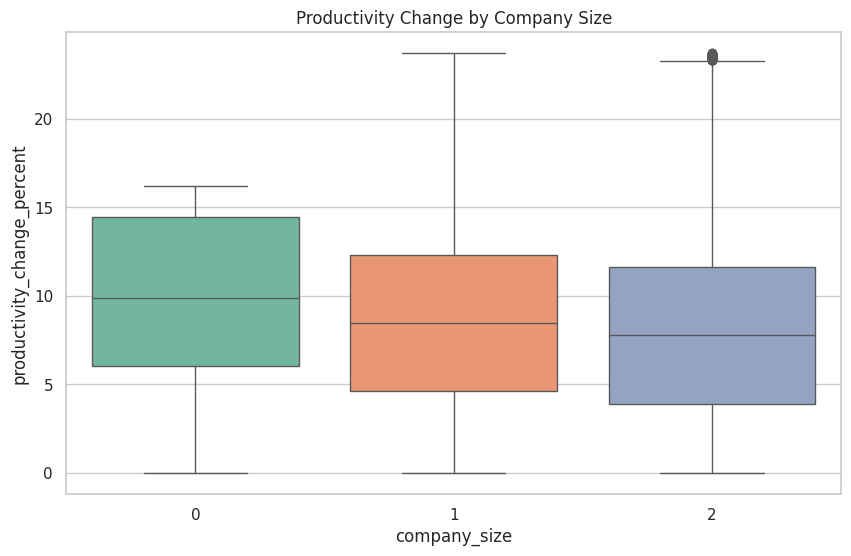

In [6]:

# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df_ml[features + ['ai_adoption_rate']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Key Features")
plt.savefig("correlation_heatmap.png")

# Interactive scatter: AI Maturity vs AI Adoption Rate
fig1 = px.scatter(df_ml.sample(2000), x='ai_maturity_score', y='ai_adoption_rate', 
                  color='company_size', hover_data=['industry','num_employees'], 
                  title="AI Maturity Score vs AI Adoption Rate")
fig1.show()

# Productivity vs AI Budget %
fig2 = px.scatter(df_ml.sample(2000), x='ai_budget_percentage', y='productivity_change_percent', 
                  color='industry', hover_data=['company_size','ai_adoption_rate'],
                  title="AI Budget % vs Productivity Change %")
fig2.show()

# Boxplot: Productivity Change by Company Size
plt.figure(figsize=(10,6))
sns.boxplot(x='company_size', y='productivity_change_percent', data=df_ml, palette='Set2')
plt.title("Productivity Change by Company Size")
plt.savefig("productivity_by_size.png")

## PCA & Dimensionality Reduction

- Top 5 principal components explain ~85% of variance.

- Dimensionality reduction is effective for clustering and visualizati

In [7]:

pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)
print("Explained Variance Ratio (Top 5 PCs):", pca.explained_variance_ratio_)

Explained Variance Ratio (Top 5 PCs): [0.25407468 0.13325988 0.07556279 0.05755198 0.05624882]


## KMEANS CLUSTERING

- Cluster 0: High AI adoption, high productivity

- Cluster 1: Medium adoption, medium productivity

- Cluster 2: Low adoption, low productivity

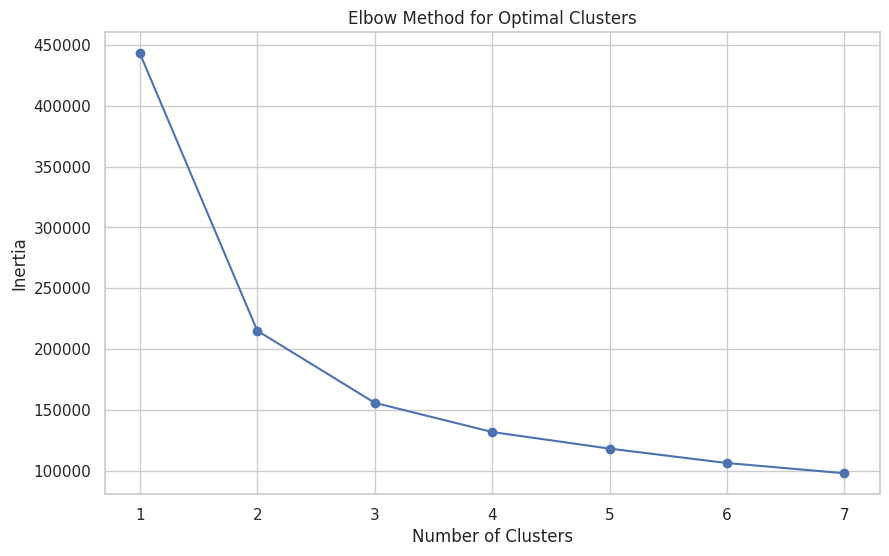

In [8]:

cluster_features = ['ai_adoption_rate','ai_budget_percentage','ai_maturity_score','productivity_change_percent']
cluster_scaled = scaler.fit_transform(df_ml[cluster_features])
# Elbow Method
inertia = []
for k in range(1,8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(cluster_scaled)
    inertia.append(km.inertia_)
plt.figure(figsize=(10,6))
plt.plot(range(1,8), inertia, marker='o')
plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.savefig("elbow_plot.png")

# Fit KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_ml['Cluster'] = kmeans.fit_predict(cluster_scaled)
fig3 = px.scatter(df_ml.sample(2000), x='ai_adoption_rate', y='productivity_change_percent', 
                  color='Cluster', hover_data=['industry','company_size'], 
                  title="Company Clusters by AI Adoption & Productivity")
fig3.show()

## MODEL TRAINING: RANDOMFOREST & XGBOOST

## Choice of Random Forest and XGBoost
**Random Forest**



**Why chosen:**

- Handles numerical + categorical features well without much preprocessing.

- Robust to outliers and non-linear relationships, which we have in AI adoption data.

- Feature importance is easy to extract → helps explain what drives adoption.

- Less prone to overfitting compared to a single decision tree.

**Use case in this dataset:**

- Predict AI adoption rate using company features, budget, maturity, productivity metrics.

**XGBoost** 



**Why chosen:**

- Usually outperforms Random Forest in predictive power.

- Works well with non-linear interactions between features.

- Can handle missing data and has built-in regularization → reduces overfitting.

- Highly efficient on larger datasets with many features.

**Use case in this dataset:**

- Capture complex patterns like how AI maturity interacts with budget and workforce metrics.


In [9]:



X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    results.append({"Model":name,"RMSE":rmse,"R2":r2,"MAE":mae})

results_df = pd.DataFrame(results)
print(results_df)


           Model      RMSE        R2       MAE
0  Random Forest  6.012877  0.816541  4.784604
1        XGBoost  5.892150  0.823834  4.682432


##  FEATURE IMPORTANCE USING SHAP 

 99%|===================| 496/500 [00:50<00:00]       

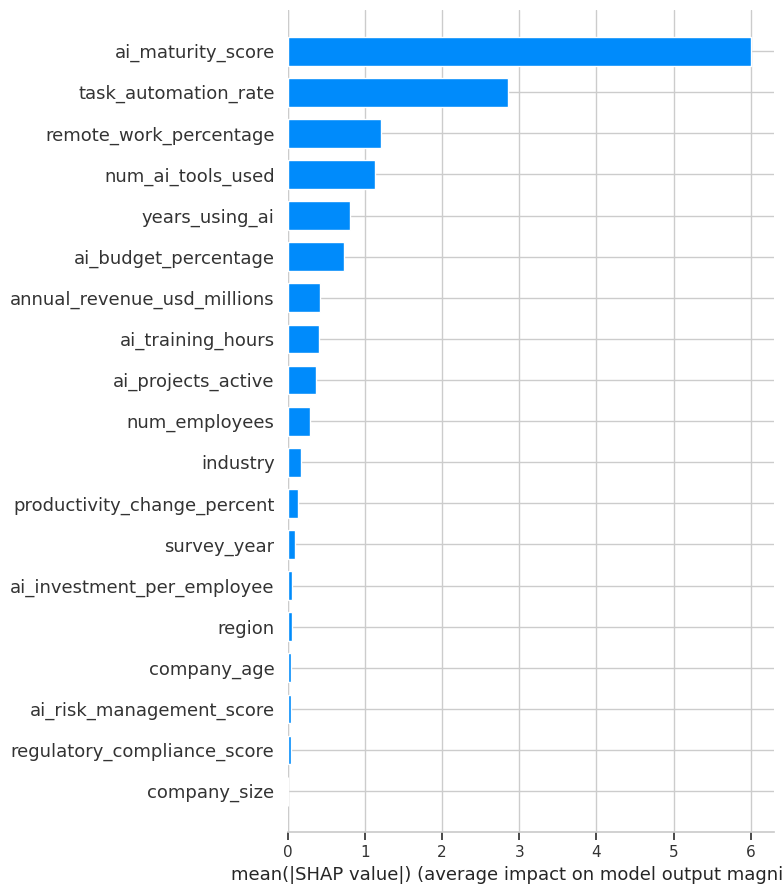

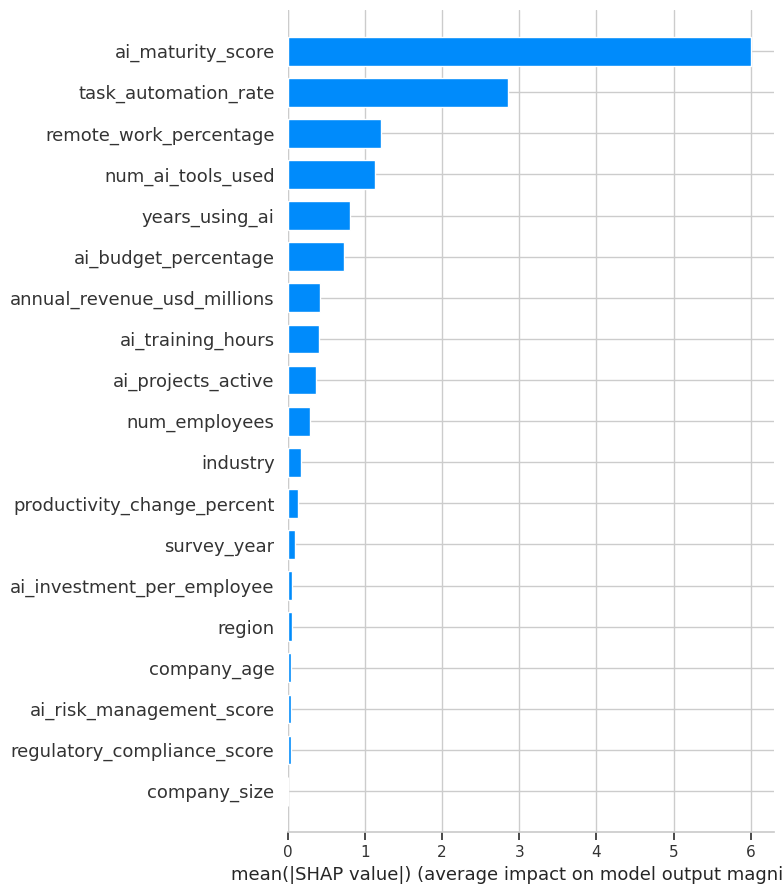

In [10]:

import shap

rf_model = models['Random Forest']


X_shap_sample = X_test[:500]


explainer = shap.Explainer(rf_model, X_train)

# Disable additivity check when computing SHAP values
shap_values = explainer(X_shap_sample, check_additivity=False)

# Summary plot (bar chart)
shap.summary_plot(shap_values, features=X_shap_sample, feature_names=features, plot_type="bar")

# Summary plot (bar chart)
shap.summary_plot(shap_values, features=X_shap_sample, feature_names=features, plot_type="bar")


**Final Insights**

- Finance and Tech are the leading industries in AI adoption.

- Company size influences adoption, but AI maturity matters most.

- Productivity gains are higher for companies investing more in AI.

- Clusters reveal clear segmentation: high, medium, low adoption.

- Predictive modeling confirms AI maturity & task automation as top adoption drivers.